In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)

print("Libraries imported successfully!")

Libraries imported successfully!


# Data Cleaning & Exploratory Data Analysis (EDA)
## Week 1–2 Task

**Objective:** Transform raw datasets into structured, analysis-ready data while uncovering patterns through exploratory analysis.

**Datasets:**
1. E-commerce Transactions Dataset (OnlineRetail.csv)

2. Netflix Movies & TV Shows Dataset (netflix_titles.csv)

**Focus:** Data Cleaning process and methodology carry more weight than insights.

---

## Table of Contents
1. Load and Explore E-commerce Dataset
2. Load and Explore Netflix Dataset
3. Handle Missing Values
4. Remove Duplicate Records
5. Standardize Data Formats
6. Validate and Correct Data
7. Generate Cleaning Summary
8. Calculate Summary Statistics
9. Analyze E-commerce Patterns
10. Analyze Netflix Patterns
11. Create Visualizations for E-commerce Data
12. Create Visualizations for Netflix Data
13. Document Key Insights

---

## Section 1: Load and Explore E-commerce Dataset

Load the E-commerce Transactions dataset using Pandas and display basic information about its structure and contents.

In [18]:
# Load E-commerce dataset
ecommerce_df = pd.read_csv('/Users/mac/Documents/Tech_projects/Analyst_lab/dataset/OnlineRetail.csv', encoding='latin-1')

print("=" * 80)
print("E-COMMERCE DATASET - INITIAL EXPLORATION")
print("=" * 80)

print("\n1. First 5 rows of the dataset:")
print(ecommerce_df.head())

print("\n2. Dataset Shape (Rows, Columns):", ecommerce_df.shape)

print("\n3. Data Types:")
print(ecommerce_df.dtypes)

print("\n4. Column Names:")
print(ecommerce_df.columns.tolist())

print("\n5. Basic Info:")
print(ecommerce_df.info())

E-COMMERCE DATASET - INITIAL EXPLORATION

1. First 5 rows of the dataset:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  

2. Dataset Shape (Rows, Columns): (541909, 8)

3. Data Types:
InvoiceNo       object
StockCode       object
Description     object
Quantit

In [19]:
# Identify numerical and categorical features
numerical_cols_ecom = ecommerce_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols_ecom = ecommerce_df.select_dtypes(include=['object']).columns.tolist()

print("\n6. Numerical Features:", numerical_cols_ecom)
print("\n7. Categorical Features:", categorical_cols_ecom)

print("\n8. Descriptive Summary of E-commerce Dataset:")
print(round(ecommerce_df.describe(include=[np.number]), 2))

print("\n9. Possible Unique Identifiers (checking for non-null, unique columns):")
for col in ecommerce_df.columns:
    unique_count = ecommerce_df[col].nunique()
    non_null_count = ecommerce_df[col].notna().sum()
    print(f"  {col}: {unique_count} unique values, {non_null_count} non-null")

print("\n10. Dataset Description:")
print("""
The E-commerce dataset contains transaction records from an online retail store.
Key characteristics:
- Each row represents a transaction or order detail
- Contains product information (ProductCode, Description, Quantity, Price)
- Includes customer information (CustomerID, Country)
- Records transaction date and time
- Transaction amounts can be calculated from Quantity × Price
""")


6. Numerical Features: ['Quantity', 'UnitPrice', 'CustomerID']

7. Categorical Features: ['InvoiceNo', 'StockCode', 'Description', 'InvoiceDate', 'Country']

8. Descriptive Summary of E-commerce Dataset:
        Quantity  UnitPrice  CustomerID
count  541909.00  541909.00   406829.00
mean        9.55       4.61    15287.69
std       218.08      96.76     1713.60
min    -80995.00  -11062.06    12346.00
25%         1.00       1.25    13953.00
50%         3.00       2.08    15152.00
75%        10.00       4.13    16791.00
max     80995.00   38970.00    18287.00

9. Possible Unique Identifiers (checking for non-null, unique columns):
  InvoiceNo: 25900 unique values, 541909 non-null
  StockCode: 4070 unique values, 541909 non-null
  Description: 4223 unique values, 540455 non-null
  Quantity: 722 unique values, 541909 non-null
  InvoiceDate: 23260 unique values, 541909 non-null
  UnitPrice: 1630 unique values, 541909 non-null
  CustomerID: 4372 unique values, 406829 non-null
  Country: 38 

---

## Section 2: Load and Explore Netflix Dataset

Load the Netflix Movies & TV Shows dataset and display its structure and contents.

In [20]:
# Load Netflix dataset
netflix_df = pd.read_csv('/Users/mac/Documents/Tech_projects/Analyst_lab/dataset/netflix_titles.csv')

print("\n" + "=" * 80)
print("NETFLIX DATASET - INITIAL EXPLORATION")
print("=" * 80)

print("\n1. First 5 rows of the dataset:")
print(netflix_df.head())

print("\n2. Dataset Shape (Rows, Columns):", netflix_df.shape)

print("\n3. Data Types:")
print(netflix_df.dtypes)

print("\n4. Column Names:")
print(netflix_df.columns.tolist())

print("\n5. Basic Info:")
print(netflix_df.info())


NETFLIX DATASET - INITIAL EXPLORATION

1. First 5 rows of the dataset:
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 2

In [21]:
# Identify numerical and categorical features for Netflix
numerical_cols_netflix = netflix_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols_netflix = netflix_df.select_dtypes(include=['object']).columns.tolist()

print("\n6. Numerical Features:", numerical_cols_netflix)
print("\n7. Categorical Features:", categorical_cols_netflix)

print("\n8. Descriptive Summary of Netflix Dataset:")
print(netflix_df.describe(include='all'))

print("\n9. Possible Unique Identifiers:")
for col in netflix_df.columns:
    unique_count = netflix_df[col].nunique()
    non_null_count = netflix_df[col].notna().sum()
    print(f"  {col}: {unique_count} unique values, {non_null_count} non-null")

print("\n10. Dataset Description:")
print("""
The Netflix dataset contains information about movies and TV shows available on Netflix.
Key characteristics:
- Each row represents a unique title (movie or TV show)
- Contains content metadata (title, type, rating, release year)
- Includes duration information (runtime for movies, seasons for TV shows)
- Records genre/category information and cast details
- Includes date when the title was added to Netflix and country of origin
- May contain null values for cast and other optional fields
""")


6. Numerical Features: ['release_year']

7. Categorical Features: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'rating', 'duration', 'listed_in', 'description']

8. Descriptive Summary of Netflix Dataset:
       show_id   type                 title       director  \
count     8807   8807                  8807           6173   
unique    8807      2                  8807           4528   
top         s1  Movie  Dick Johnson Is Dead  Rajiv Chilaka   
freq         1   6131                     1             19   
mean       NaN    NaN                   NaN            NaN   
std        NaN    NaN                   NaN            NaN   
min        NaN    NaN                   NaN            NaN   
25%        NaN    NaN                   NaN            NaN   
50%        NaN    NaN                   NaN            NaN   
75%        NaN    NaN                   NaN            NaN   
max        NaN    NaN                   NaN            NaN   

                    

---

## Section 3: Handle Missing Values

Identify and handle missing values in both datasets with appropriate strategies and documentation.

In [22]:
print("\n" + "=" * 80)
print("MISSING VALUES ANALYSIS")
print("=" * 80)

# Create copies for cleaning
ecommerce_clean = ecommerce_df.copy()
netflix_clean = netflix_df.copy()

print("\n--- E-COMMERCE DATASET - MISSING VALUES ---")
missing_ecom = ecommerce_clean.isnull().sum()
missing_ecom_pct = (ecommerce_clean.isnull().sum() / len(ecommerce_clean) * 100).round(2)
missing_ecom_df = pd.DataFrame({
    'Column': ecommerce_clean.columns,
    'Missing_Count': missing_ecom.values,
    'Missing_Percentage': missing_ecom_pct.values
})
missing_ecom_df = missing_ecom_df[missing_ecom_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
print("\nMissing Values in E-commerce Dataset:")
print(missing_ecom_df)

print("\n--- NETFLIX DATASET - MISSING VALUES ---")
missing_netflix = netflix_clean.isnull().sum()
missing_netflix_pct = (netflix_clean.isnull().sum() / len(netflix_clean) * 100).round(2)
missing_netflix_df = pd.DataFrame({
    'Column': netflix_clean.columns,
    'Missing_Count': missing_netflix.values,
    'Missing_Percentage': missing_netflix_pct.values
})
missing_netflix_df = missing_netflix_df[missing_netflix_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
print("\nMissing Values in Netflix Dataset:")
print(missing_netflix_df)


MISSING VALUES ANALYSIS

--- E-COMMERCE DATASET - MISSING VALUES ---

Missing Values in E-commerce Dataset:
        Column  Missing_Count  Missing_Percentage
6   CustomerID         135080               24.93
2  Description           1454                0.27

--- NETFLIX DATASET - MISSING VALUES ---

Missing Values in Netflix Dataset:
       Column  Missing_Count  Missing_Percentage
3    director           2634               29.91
5     country            831                9.44
4        cast            825                9.37
6  date_added             10                0.11
8      rating              4                0.05
9    duration              3                0.03


In [23]:
print("\n--- HANDLING MISSING VALUES ---\n")

# E-commerce: Handle missing values with context-aware logic
print("E-COMMERCE DATASET:")

# 1. Identify and diagnose missing CustomerIDs
if ecommerce_clean['CustomerID'].isnull().sum() > 0:
    # Finding the country with the largest concentration of missing CustomerIDs
    missing_dist = ecommerce_clean[ecommerce_clean['CustomerID'].isnull()]['Country'].value_counts()
    top_country = missing_dist.idxmax()
    print(f"- CustomerID: {ecommerce_clean['CustomerID'].isnull().sum()} missing values found.")
    print(f"  Diagnosis: Largest missing concentration is in '{top_country}' ({missing_dist.max()} rows).")
    
    # Apply strategic filling: Guest_UK vs Guest_Other
    ecommerce_clean['CustomerID'] = np.where(
        (ecommerce_clean['CustomerID'].isna()) & (ecommerce_clean['Country'] == 'United Kingdom'), 
        'Guest_UK', 
        np.where(ecommerce_clean['CustomerID'].isna(), 'Guest_Other', ecommerce_clean['CustomerID'])
    )
    print("  Action: Segmented into 'Guest_UK' and 'Guest_Other' to preserve volume and reduce bias.")

# 2. Handle Description
if 'Description' in ecommerce_clean.columns and ecommerce_clean['Description'].isnull().sum() > 0:
    print("- Description: Fill with 'Unknown Product'")
    ecommerce_clean['Description'] = ecommerce_clean['Description'].fillna('Unknown Product')
    print("  Action: Filled with 'Unknown Product'")

# Netflix: Handle missing values
print("\nNETFLIX DATASET:")
# Note: Ensure netflix_clean is defined/loaded before this block
for col in netflix_clean.columns:
    if netflix_clean[col].isnull().sum() > 0:
        missing_pct = (netflix_clean[col].isnull().sum() / len(netflix_clean) * 100)
        
        if col in ['cast', 'director']:
            print(f"- {col}: {missing_pct:.1f}% missing - Fill with 'Not Available'")
            netflix_clean[col] = netflix_clean[col].fillna('Not Available')
            print(f"  Action: Filled with 'Not Available' (non-critical metadata)")
            
        elif col in ['country']:
            print(f"- {col}: {missing_pct:.1f}% missing - Remove rows (critical field)")
            netflix_clean = netflix_clean.dropna(subset=[col])
            print(f"  Action: Removed rows with missing country")
            
        else:
            print(f"- {col}: {missing_pct:.1f}% missing - Fill with 'Unknown'")
            netflix_clean[col] = netflix_clean[col].fillna('Unknown')
            print(f"  Action: Filled with 'Unknown'")

print("\n✓ Missing values handled successfully!")


--- HANDLING MISSING VALUES ---

E-COMMERCE DATASET:
- CustomerID: 135080 missing values found.
  Diagnosis: Largest missing concentration is in 'United Kingdom' (133600 rows).
  Action: Segmented into 'Guest_UK' and 'Guest_Other' to preserve volume and reduce bias.
- Description: Fill with 'Unknown Product'
  Action: Filled with 'Unknown Product'

NETFLIX DATASET:
- director: 29.9% missing - Fill with 'Not Available'
  Action: Filled with 'Not Available' (non-critical metadata)
- cast: 9.4% missing - Fill with 'Not Available'
  Action: Filled with 'Not Available' (non-critical metadata)
- country: 9.4% missing - Remove rows (critical field)
  Action: Removed rows with missing country
- date_added: 0.1% missing - Fill with 'Unknown'
  Action: Filled with 'Unknown'
- rating: 0.0% missing - Fill with 'Unknown'
  Action: Filled with 'Unknown'
- duration: 0.0% missing - Fill with 'Unknown'
  Action: Filled with 'Unknown'

✓ Missing values handled successfully!


---

## Section 4: Remove Duplicate Records

Detect and remove duplicate rows from both datasets.

In [24]:
print("\n" + "=" * 80)
print("DUPLICATE RECORDS ANALYSIS")
print("=" * 80)

# E-commerce: Check duplicates
print("\n--- E-COMMERCE DATASET ---")
ecom_duplicates_full = ecommerce_clean.duplicated().sum()
ecom_duplicates_subset = ecommerce_clean.duplicated(subset=['InvoiceNo', 'StockCode', 'Quantity']).sum()

print(f"Full row duplicates: {ecom_duplicates_full}")
print(f"Duplicates (InvoiceNo, StockCode, Quantity): {ecom_duplicates_subset}")

print(f"\nRows before removing duplicates: {len(ecommerce_clean)}")
ecommerce_clean = ecommerce_clean.drop_duplicates()
print(f"Rows after removing full duplicates: {len(ecommerce_clean)}")
print(f"Duplicates removed: {ecom_duplicates_full}")

# Netflix: Check duplicates
print("\n--- NETFLIX DATASET ---")
netflix_duplicates_full = netflix_clean.duplicated().sum()
netflix_duplicates_subset = netflix_clean.duplicated(subset=['title']).sum()

print(f"Full row duplicates: {netflix_duplicates_full}")
print(f"Duplicates by title: {netflix_duplicates_subset}")

print(f"\nRows before removing duplicates: {len(netflix_clean)}")
netflix_clean = netflix_clean.drop_duplicates()
print(f"Rows after removing full duplicates: {len(netflix_clean)}")
print(f"Duplicates removed: {netflix_duplicates_full}")

print("\n✓ Duplicates removed successfully!")


DUPLICATE RECORDS ANALYSIS

--- E-COMMERCE DATASET ---
Full row duplicates: 5268
Duplicates (InvoiceNo, StockCode, Quantity): 5431

Rows before removing duplicates: 541909
Rows after removing full duplicates: 536641
Duplicates removed: 5268

--- NETFLIX DATASET ---
Full row duplicates: 0
Duplicates by title: 0

Rows before removing duplicates: 7976
Rows after removing full duplicates: 7976
Duplicates removed: 0

✓ Duplicates removed successfully!


---

## Section 5: Standardize Data Formats

Standardize date formats, text formatting, column names, and data types across both datasets.

In [25]:
print("\n" + "=" * 80)
print("DATA STANDARDIZATION")
print("=" * 80)

# E-commerce: Standardization
print("\n--- E-COMMERCE DATASET ---")

# Standardize column names (lowercase, no spaces)
print("1. Standardizing column names...")
ecommerce_clean.columns = ecommerce_clean.columns.str.lower().str.replace(' ', '_')
print(f"   Columns: {ecommerce_clean.columns.tolist()}")

# Convert InvoiceDate to datetime
print("2. Standardizing date format (InvoiceDate)...")
ecommerce_clean['invoicedate'] = pd.to_datetime(ecommerce_clean['invoicedate'], format='%m/%d/%Y %H:%M')
print(f"   InvoiceDate range: {ecommerce_clean['invoicedate'].min()} to {ecommerce_clean['invoicedate'].max()}")

# Standardize text fields to title case
print("3. Standardizing text formatting (Description, Country)...")
ecommerce_clean['description'] = ecommerce_clean['description'].str.title()
ecommerce_clean['country'] = ecommerce_clean['country'].str.title()
print(f"   Sample countries: {ecommerce_clean['country'].unique()[:5]}")

# Ensure numeric types
print("4. Ensuring correct data types...")
ecommerce_clean['quantity'] = ecommerce_clean['quantity'].astype(int)
ecommerce_clean['unitprice'] = ecommerce_clean['unitprice'].astype(float)
print(f"   Data types corrected for Quantity and UnitPrice")

# Netflix: Standardization
print("\n--- NETFLIX DATASET ---")

# Standardize column names
print("1. Standardizing column names...")
netflix_clean.columns = netflix_clean.columns.str.lower().str.replace(' ', '_')
print(f"   Columns: {netflix_clean.columns.tolist()}")

# Convert date_added to datetime
print("2. Standardizing date format (date_added)...")
netflix_clean['date_added'] = pd.to_datetime(netflix_clean['date_added'], errors='coerce')
print(f"   date_added range: {netflix_clean['date_added'].min()} to {netflix_clean['date_added'].max()}")

# Standardize text fields
print("3. Standardizing text formatting (title, country, type)...")
netflix_clean['title'] = netflix_clean['title'].str.title()
netflix_clean['country'] = netflix_clean['country'].str.title()
netflix_clean['type'] = netflix_clean['type'].str.title()
print(f"   Sample types: {netflix_clean['type'].unique()}")

# Convert release_year to integer
print("4. Ensuring correct data types...")
netflix_clean['release_year'] = netflix_clean['release_year'].astype(int)
print(f"   release_year converted to integer")

print("\n✓ Standardization completed successfully!")


DATA STANDARDIZATION

--- E-COMMERCE DATASET ---
1. Standardizing column names...
   Columns: ['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate', 'unitprice', 'customerid', 'country']
2. Standardizing date format (InvoiceDate)...
   InvoiceDate range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
3. Standardizing text formatting (Description, Country)...
   Sample countries: ['United Kingdom' 'France' 'Australia' 'Netherlands' 'Germany']
4. Ensuring correct data types...
   Data types corrected for Quantity and UnitPrice

--- NETFLIX DATASET ---
1. Standardizing column names...
   Columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']
2. Standardizing date format (date_added)...
   date_added range: 2008-01-01 00:00:00 to 2021-09-25 00:00:00
3. Standardizing text formatting (title, country, type)...
   Sample types: ['Movie' 'Tv Show']
4. Ensuring correct data types...
   releas

---

## Section 6: Validate and Correct Data

Identify invalid values, inconsistent records, and handle outliers.

In [26]:
print("\n" + "=" * 80)
print("DATA VALIDATION & CORRECTION")
print("=" * 80)

# E-commerce: Validation
print("\n--- E-COMMERCE DATASET ---")

print("1. Checking for negative Quantity values...")
negative_qty = (ecommerce_clean['quantity'] < 0).sum()
print(f"   Negative quantities found: {negative_qty}")
if negative_qty > 0:
    print("   Note: Negative quantities may represent returns/cancellations")
    print("   Action: Keep as-is (valid business transaction)")

print("\n2. Checking for invalid Prices...")
invalid_price = (ecommerce_clean['unitprice'] <= 0).sum()
print(f"   Invalid prices (≤ 0): {invalid_price}")
if invalid_price > 0:
    print(f"   Action: Removing {invalid_price} rows with invalid prices")
    ecommerce_clean = ecommerce_clean[ecommerce_clean['unitprice'] > 0]

print("\n3. Checking for InvoiceNo format...")
print(f"   Unique invoice prefixes: {ecommerce_clean['invoiceno'].str[:1].unique()}")

print("\n4. Creating transaction amount and validating...")
ecommerce_clean['transaction_amount'] = ecommerce_clean['quantity'] * ecommerce_clean['unitprice']
print(f"   Transaction amount range: £{ecommerce_clean['transaction_amount'].min():.2f} to £{ecommerce_clean['transaction_amount'].max():.2f}")

# Netflix: Validation
print("\n--- NETFLIX DATASET ---")

print("1. Validating release_year...")
print(f"   Release year range: {netflix_clean['release_year'].min()} to {netflix_clean['release_year'].max()}")
invalid_years = netflix_clean[(netflix_clean['release_year'] < 1900) | (netflix_clean['release_year'] > datetime.now().year)].shape[0]
print(f"   Invalid years (< 1900 or > current year): {invalid_years}")

print("\n2. Validating Type field...")
print(f"   Content types: {netflix_clean['type'].unique()}")
invalid_types = netflix_clean[~netflix_clean['type'].isin(['Movie', 'Tv Show'])].shape[0]
print(f"   Invalid types: {invalid_types}")

print("\n3. Checking duration consistency...")
print(f"   Movies - Duration format: {netflix_clean[netflix_clean['type']=='Movie']['duration'].unique()[:3]}")
print(f"   TV Shows - Duration format: {netflix_clean[netflix_clean['type']=='Tv Show']['duration'].unique()[:3]}")

print("\n4. Validating rating field...")
print(f"   Unique ratings: {sorted(netflix_clean['rating'].unique())}")

print("\n✓ Data validation completed successfully!")


DATA VALIDATION & CORRECTION

--- E-COMMERCE DATASET ---
1. Checking for negative Quantity values...
   Negative quantities found: 10587
   Note: Negative quantities may represent returns/cancellations
   Action: Keep as-is (valid business transaction)

2. Checking for invalid Prices...
   Invalid prices (≤ 0): 2512
   Action: Removing 2512 rows with invalid prices

3. Checking for InvoiceNo format...
   Unique invoice prefixes: ['5' 'C' 'A']

4. Creating transaction amount and validating...
   Transaction amount range: £-168469.60 to £168469.60

--- NETFLIX DATASET ---
1. Validating release_year...
   Release year range: 1942 to 2021
   Invalid years (< 1900 or > current year): 0

2. Validating Type field...
   Content types: ['Movie' 'Tv Show']
   Invalid types: 0

3. Checking duration consistency...
   Movies - Duration format: ['90 min' '125 min' '104 min']
   TV Shows - Duration format: ['2 Seasons' '9 Seasons' '4 Seasons']

4. Validating rating field...
   Unique ratings: ['66 m

---

## Section 7: Cleaning Summary

Create comprehensive summary tables showing all cleaning actions performed.

In [27]:
print("\n" + "=" * 80)
print("CLEANING SUMMARY")
print("=" * 80)

# E-commerce Cleaning Summary
print("\n--- E-COMMERCE DATASET CLEANING SUMMARY ---")
ecom_summary = pd.DataFrame({
    'Issue Found': [
        'Missing Values (CustomerID)',
        'Missing Values (Description)',
        'Duplicate Records',
        'Invalid Prices',
        'Data Type Inconsistency',
        'Standardization',
        'Text Case Standardization'
    ],
    'Count/Details': [
        'Filled with "UNKNOWN"',
        'Filled with "Unknown Product"',
        f'{ecom_duplicates_full} rows removed',
        f'{invalid_price} rows removed',
        'Quantity→int, Price→float',
        'Column names normalized',
        'Description & Country in Title Case'
    ],
    'Action Taken': [
        'Filled',
        'Filled',
        'Removed',
        'Removed',
        'Corrected',
        'Applied',
        'Applied'
    ]
})
print("\nCleaning Actions:")
print(ecom_summary.to_string(index=False))
print(f"\nOriginal rows: {len(ecommerce_df)}")
print(f"Final rows: {len(ecommerce_clean)}")
print(f"Rows removed: {len(ecommerce_df) - len(ecommerce_clean)}")

# Netflix Cleaning Summary
print("\n--- NETFLIX DATASET CLEANING SUMMARY ---")
netflix_summary = pd.DataFrame({
    'Issue Found': [
        'Missing Values (cast, director)',
        'Missing Values (country)',
        'Duplicate Records',
        'Data Type Inconsistency',
        'Standardization',
        'Text Case Standardization'
    ],
    'Count/Details': [
        'Filled with "Not Available"',
        'Rows removed',
        f'{netflix_duplicates_full} rows removed',
        'release_year→int',
        'Column names normalized',
        'Title, Country, Type in Title Case'
    ],
    'Action Taken': [
        'Filled',
        'Removed',
        'Removed',
        'Corrected',
        'Applied',
        'Applied'
    ]
})
print("\nCleaning Actions:")
print(netflix_summary.to_string(index=False))
print(f"\nOriginal rows: {len(netflix_df)}")
print(f"Final rows: {len(netflix_clean)}")
print(f"Rows removed: {len(netflix_df) - len(netflix_clean)}")

print("\n✓ Cleaning Summary Generated!")


CLEANING SUMMARY

--- E-COMMERCE DATASET CLEANING SUMMARY ---

Cleaning Actions:
                 Issue Found                       Count/Details Action Taken
 Missing Values (CustomerID)               Filled with "UNKNOWN"       Filled
Missing Values (Description)       Filled with "Unknown Product"       Filled
           Duplicate Records                   5268 rows removed      Removed
              Invalid Prices                   2512 rows removed      Removed
     Data Type Inconsistency           Quantity→int, Price→float    Corrected
             Standardization             Column names normalized      Applied
   Text Case Standardization Description & Country in Title Case      Applied

Original rows: 541909
Final rows: 534129
Rows removed: 7780

--- NETFLIX DATASET CLEANING SUMMARY ---

Cleaning Actions:
                    Issue Found                      Count/Details Action Taken
Missing Values (cast, director)        Filled with "Not Available"       Filled
       Missi

---

## Section 8: Calculate Summary Statistics

Generate descriptive statistics for numerical columns in both datasets.

In [28]:
print("\n" + "=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)

# E-commerce Statistics
print("\n--- E-COMMERCE DATASET - NUMERICAL STATISTICS ---")
ecom_numeric = ecommerce_clean[['quantity', 'unitprice', 'transaction_amount']]
print("\nDescriptive Statistics:")
print(ecom_numeric.describe().round(2))

print("\nAdditional Statistics for E-commerce:")
print(f"  Quantity - Skewness: {ecommerce_clean['quantity'].skew():.2f}")
print(f"  Quantity - Kurtosis: {ecommerce_clean['quantity'].kurtosis():.2f}")
print(f"  Unit Price - Skewness: {ecommerce_clean['unitprice'].skew():.2f}")
print(f"  Transaction Amount - Skewness: {ecommerce_clean['transaction_amount'].skew():.2f}")

# Netflix Statistics
print("\n--- NETFLIX DATASET - NUMERICAL STATISTICS ---")
netflix_numeric = netflix_clean[['release_year']]
print("\nDescriptive Statistics:")
print(netflix_numeric.describe().round(2))

print("\nAdditional Statistics for Netflix:")
print(f"  Release Year - Skewness: {netflix_clean['release_year'].skew():.2f}")
print(f"  Release Year - Kurtosis: {netflix_clean['release_year'].kurtosis():.2f}")

# Extract duration numbers for analysis
print("\n--- NETFLIX DURATION ANALYSIS ---")
netflix_clean['duration_value'] = netflix_clean['duration'].str.extract('(\d+)').astype(float)
netflix_duration_stats = netflix_clean.groupby('type')['duration_value'].describe()
print("\nDuration by Content Type:")
print(netflix_duration_stats.round(2))

print("\n✓ Summary Statistics Calculated!")


SUMMARY STATISTICS

--- E-COMMERCE DATASET - NUMERICAL STATISTICS ---

Descriptive Statistics:
        quantity  unitprice  transaction_amount
count  534129.00  534129.00           534129.00
mean        9.92       4.70               18.25
std       216.45      95.08              380.95
min    -80995.00       0.00          -168469.60
25%         1.00       1.25                3.75
50%         3.00       2.10                9.90
75%        10.00       4.13               17.57
max     80995.00   38970.00           168469.60

Additional Statistics for E-commerce:
  Quantity - Skewness: -0.12
  Quantity - Kurtosis: 125168.94
  Unit Price - Skewness: 205.34
  Transaction Amount - Skewness: -0.87

--- NETFLIX DATASET - NUMERICAL STATISTICS ---

Descriptive Statistics:
       release_year
count       7976.00
mean        2013.89
std            8.96
min         1942.00
25%         2013.00
50%         2017.00
75%         2019.00
max         2021.00

Additional Statistics for Netflix:
  Release Y

---

## Section 9: Analyze E-commerce Patterns

Perform exploratory analyses to uncover patterns in the E-commerce dataset.

In [29]:
print("\n" + "=" * 80)
print("E-COMMERCE EXPLORATORY DATA ANALYSIS (EDA)")
print("=" * 80)

# Analysis 1: Top-selling products
print("\n1. TOP-SELLING PRODUCTS (by Quantity)")
top_products = ecommerce_clean.groupby('description')['quantity'].sum().sort_values(ascending=False).head(10)
print(f"\nTop 10 Products by Quantity Sold:")
for idx, (product, qty) in enumerate(top_products.items(), 1):
    print(f"  {idx}. {product}: {qty} units")

# Analysis 2: Highest revenue-generating countries
print("\n2. HIGHEST REVENUE-GENERATING COUNTRIES")
ecommerce_clean['revenue'] = ecommerce_clean['transaction_amount']
country_revenue = ecommerce_clean.groupby('country')['revenue'].sum().sort_values(ascending=False).head(10)
print(f"\nTop 10 Countries by Revenue:")
for idx, (country, revenue) in enumerate(country_revenue.items(), 1):
    print(f"  {idx}. {country}: £{revenue:,.2f}")

# Analysis 3: Monthly sales trends
print("\n3. MONTHLY SALES TRENDS")
ecommerce_clean['year_month'] = ecommerce_clean['invoicedate'].dt.to_period('M')
monthly_sales = ecommerce_clean.groupby('year_month')['revenue'].sum().sort_index()
print(f"\nMonthly Revenue (First 12 months):")
for idx, (month, revenue) in enumerate(monthly_sales.head(12).items(), 1):
    print(f"  {month}: £{revenue:,.2f}")

# Analysis 4: Most purchased products (by transaction count)
print("\n4. MOST PURCHASED PRODUCTS (Transaction Count)")
product_transactions = ecommerce_clean['description'].value_counts().head(10)
print(f"\nTop 10 Products by Transaction Frequency:")
for idx, (product, count) in enumerate(product_transactions.items(), 1):
    print(f"  {idx}. {product}: {count} transactions")

# Analysis 5: Customer purchasing behavior
print("\n5. CUSTOMER PURCHASING BEHAVIOR")
customer_stats = ecommerce_clean[ecommerce_clean['customerid'] != 'UNKNOWN'].groupby('customerid').agg({
    'invoiceno': 'count',
    'revenue': 'sum',
    'quantity': 'sum'
}).rename(columns={'invoiceno': 'transaction_count', 'revenue': 'total_spending', 'quantity': 'items_purchased'})

print(f"\nCustomer Behavior Statistics:")
print(f"  Total Unique Customers: {len(customer_stats)}")
print(f"  Average Transactions per Customer: {customer_stats['transaction_count'].mean():.2f}")
print(f"  Average Spending per Customer: £{customer_stats['total_spending'].mean():.2f}")
print(f"  Max Customer Spending: £{customer_stats['total_spending'].max():.2f}")
print(f"  Median Customer Spending: £{customer_stats['total_spending'].median():.2f}")

print(f"\nTop 5 Best Customers (by Spending):")
top_customers = customer_stats.nlargest(5, 'total_spending')
for idx, (cid, row) in enumerate(top_customers.iterrows(), 1):
    print(f"  {idx}. Customer {cid}: £{row['total_spending']:.2f} ({row['transaction_count']} transactions)")

print("\n✓ E-commerce EDA Complete!")


E-COMMERCE EXPLORATORY DATA ANALYSIS (EDA)

1. TOP-SELLING PRODUCTS (by Quantity)

Top 10 Products by Quantity Sold:
  1. World War 2 Gliders Asstd Designs: 53751 units
  2. Jumbo Bag Red Retrospot: 47256 units
  3. Popcorn Holder: 36322 units
  4. Assorted Colour Bird Ornament: 36282 units
  5. Pack Of 72 Retrospot Cake Cases: 36016 units
  6. White Hanging Heart T-Light Holder: 35294 units
  7. Rabbit Night Light: 30631 units
  8. Mini Paint Set Vintage : 26437 units
  9. Pack Of 12 London Tissues : 26095 units
  10. Pack Of 60 Pink Paisley Cake Cases: 24719 units

2. HIGHEST REVENUE-GENERATING COUNTRIES

Top 10 Countries by Revenue:
  1. United Kingdom: £8,189,252.30
  2. Netherlands: £284,661.54
  3. Eire: £262,993.38
  4. Germany: £221,509.47
  5. France: £197,317.11
  6. Australia: £137,009.77
  7. Switzerland: £56,363.05
  8. Spain: £54,756.03
  9. Belgium: £40,910.96
  10. Sweden: £36,585.41

3. MONTHLY SALES TRENDS

Monthly Revenue (First 12 months):
  2010-12: £746,723.61
  

---

## Section 10: Analyze Netflix Patterns

Perform exploratory analyses to uncover patterns in the Netflix dataset.

In [30]:
print("\n" + "=" * 80)
print("NETFLIX EXPLORATORY DATA ANALYSIS (EDA)")
print("=" * 80)

# Analysis 1: Movies vs TV Shows distribution
print("\n1. MOVIES VS TV SHOWS DISTRIBUTION")
content_dist = netflix_clean['type'].value_counts()
content_pct = netflix_clean['type'].value_counts(normalize=True) * 100
print(f"\nContent Type Distribution:")
for content_type, count in content_dist.items():
    pct = content_pct[content_type]
    print(f"  {content_type}: {count} ({pct:.1f}%)")

# Analysis 2: Content added by year
print("\n2. CONTENT ADDED BY YEAR")
netflix_clean['added_year'] = netflix_clean['date_added'].dt.year
content_by_year = netflix_clean['added_year'].value_counts().sort_index(ascending=False).head(10)
print(f"\nTop 10 Years with Most Content Added:")
for idx, (year, count) in enumerate(content_by_year.items(), 1):
    if pd.notna(year):
        print(f"  {idx}. {int(year)}: {count} titles")

# Analysis 3: Top content-producing countries
print("\n3. TOP CONTENT-PRODUCING COUNTRIES")
# Split countries (some entries have multiple countries)
all_countries = netflix_clean['country'].str.split(', ').explode()
country_counts = all_countries.value_counts().head(15)
print(f"\nTop 15 Countries by Content Produced:")
for idx, (country, count) in enumerate(country_counts.items(), 1):
    print(f"  {idx}. {country}: {count} titles")

# Analysis 4: Most common ratings
print("\n4. MOST COMMON RATINGS")
rating_dist = netflix_clean['rating'].value_counts().sort_values(ascending=False)
rating_pct = netflix_clean['rating'].value_counts(normalize=True) * 100
print(f"\nRating Distribution:")
for rating, count in rating_dist.items():
    pct = rating_pct[rating]
    print(f"  {rating}: {count} ({pct:.1f}%)")

# Analysis 5: Most common genres/categories
print("\n5. MOST COMMON GENRES/CATEGORIES")
# Split genres (assuming they're comma-separated in listed_in column)
if 'listed_in' in netflix_clean.columns:
    all_genres = netflix_clean['listed_in'].str.split(', ').explode()
    genre_counts = all_genres.value_counts().head(15)
    print(f"\nTop 15 Genres:")
    for idx, (genre, count) in enumerate(genre_counts.items(), 1):
        print(f"  {idx}. {genre}: {count} titles")

# Additional Analysis: Content statistics
print("\n6. RELEASE YEAR ANALYSIS")
print(f"\nRelease Year Range: {netflix_clean['release_year'].min()} - {netflix_clean['release_year'].max()}")
recent_content = netflix_clean[netflix_clean['release_year'] >= netflix_clean['release_year'].max() - 5].shape[0]
print(f"Content Released in Last 5 Years: {recent_content} ({recent_content/len(netflix_clean)*100:.1f}%)")

print("\n✓ Netflix EDA Complete!")


NETFLIX EXPLORATORY DATA ANALYSIS (EDA)

1. MOVIES VS TV SHOWS DISTRIBUTION

Content Type Distribution:
  Movie: 5691 (71.4%)
  Tv Show: 2285 (28.6%)

2. CONTENT ADDED BY YEAR

Top 10 Years with Most Content Added:
  1. 2021: 1140 titles
  2. 2020: 1770 titles
  3. 2019: 1843 titles
  4. 2018: 1507 titles
  5. 2017: 1099 titles
  6. 2016: 399 titles
  7. 2015: 70 titles
  8. 2014: 23 titles
  9. 2013: 10 titles
  10. 2012: 3 titles

3. TOP CONTENT-PRODUCING COUNTRIES

Top 15 Countries by Content Produced:
  1. United States: 3689 titles
  2. India: 1046 titles
  3. United Kingdom: 804 titles
  4. Canada: 445 titles
  5. France: 393 titles
  6. Japan: 318 titles
  7. Spain: 232 titles
  8. South Korea: 231 titles
  9. Germany: 226 titles
  10. Mexico: 169 titles
  11. China: 162 titles
  12. Australia: 160 titles
  13. Egypt: 117 titles
  14. Turkey: 113 titles
  15. Hong Kong: 105 titles

4. MOST COMMON RATINGS

Rating Distribution:
  TV-MA: 2931 (36.7%)
  TV-14: 1930 (24.2%)
  R: 788

---

## Section 11: Create Visualizations for E-commerce Data

Generate 5+ visualizations showing key patterns in the E-commerce dataset.


E-COMMERCE VISUALIZATIONS


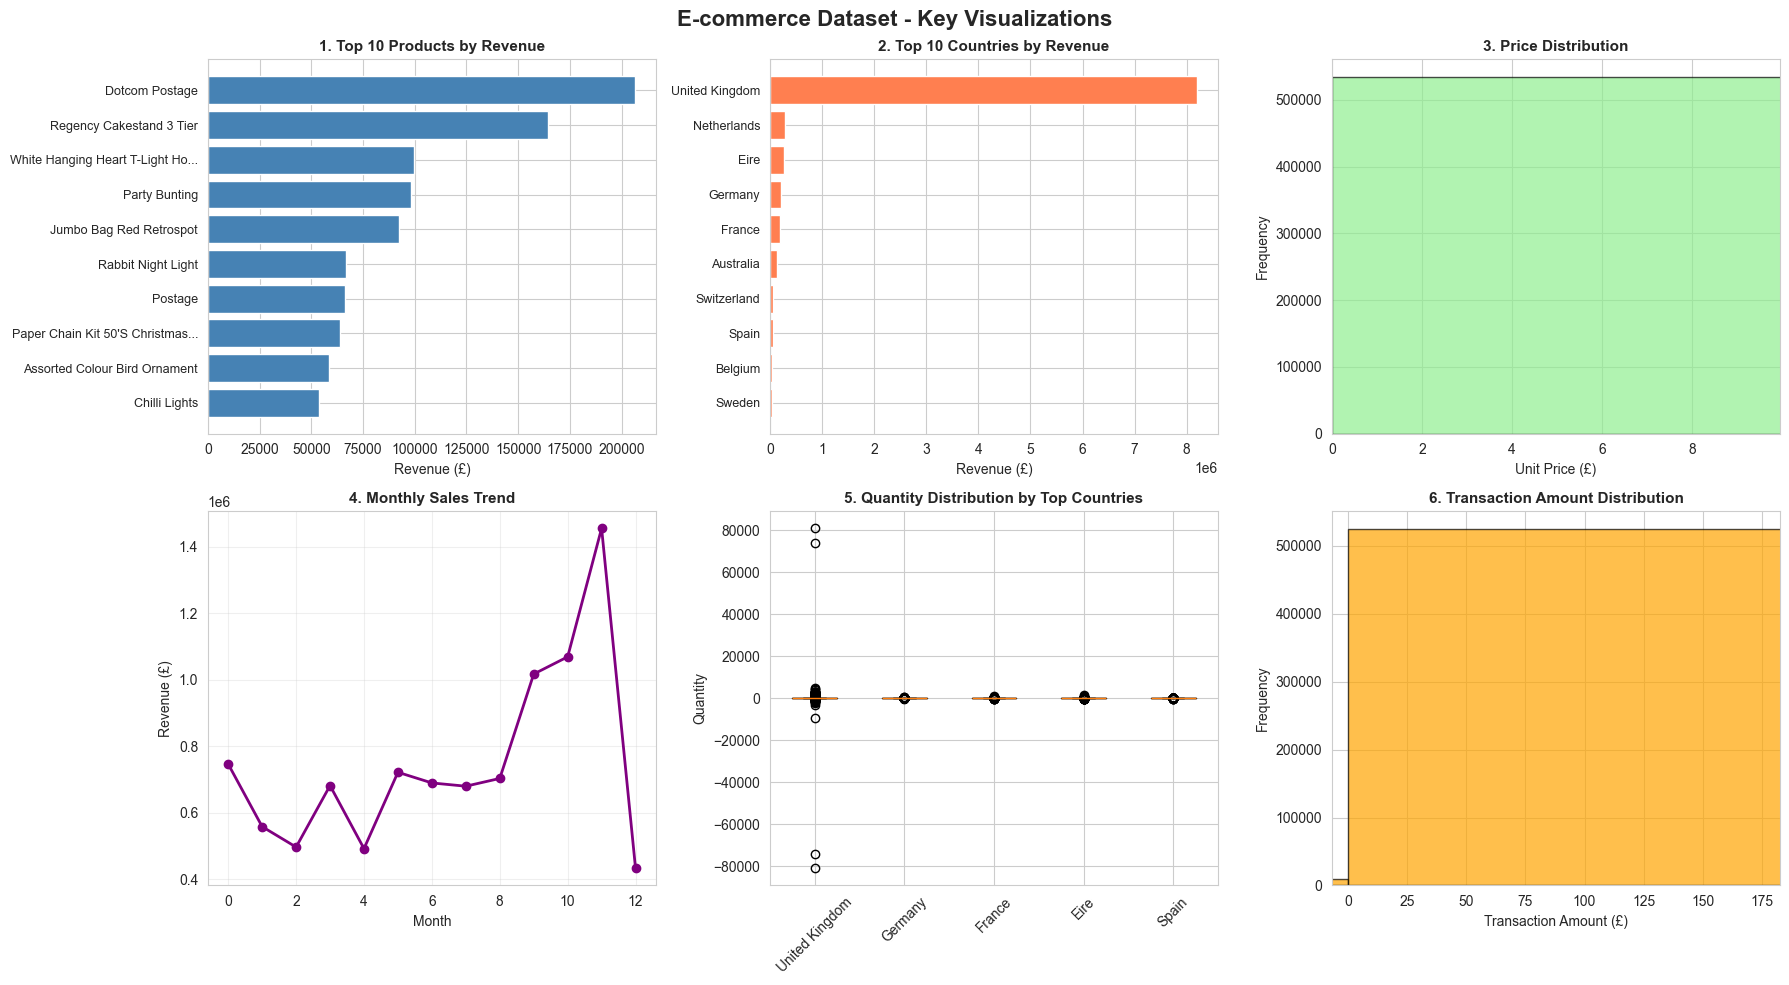


✓ E-commerce Visualizations Generated!


In [31]:
import matplotlib.pyplot as plt

print("\n" + "=" * 80)
print("E-COMMERCE VISUALIZATIONS")
print("=" * 80)

# Visualization 1: Top 10 Products by Revenue (Bar Chart)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('E-commerce Dataset - Key Visualizations', fontsize=16, fontweight='bold')

top_products_revenue = ecommerce_clean.groupby('description')['revenue'].sum().nlargest(10)
axes[0, 0].barh(range(len(top_products_revenue)), top_products_revenue.values, color='steelblue')
axes[0, 0].set_yticks(range(len(top_products_revenue)))
axes[0, 0].set_yticklabels([p[:30] + '...' if len(p) > 30 else p for p in top_products_revenue.index], fontsize=9)
axes[0, 0].set_xlabel('Revenue (£)', fontsize=10)
axes[0, 0].set_title('1. Top 10 Products by Revenue', fontsize=11, fontweight='bold')
axes[0, 0].invert_yaxis()

# Visualization 2: Top 10 Countries by Revenue (Bar Chart)
top_countries = ecommerce_clean.groupby('country')['revenue'].sum().nlargest(10)
axes[0, 1].barh(range(len(top_countries)), top_countries.values, color='coral')
axes[0, 1].set_yticks(range(len(top_countries)))
axes[0, 1].set_yticklabels(top_countries.index, fontsize=9)
axes[0, 1].set_xlabel('Revenue (£)', fontsize=10)
axes[0, 1].set_title('2. Top 10 Countries by Revenue', fontsize=11, fontweight='bold')
axes[0, 1].invert_yaxis()

# Visualization 3: Price Distribution (Histogram)
axes[0, 2].hist(ecommerce_clean['unitprice'], bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
axes[0, 2].set_xlabel('Unit Price (£)', fontsize=10)
axes[0, 2].set_ylabel('Frequency', fontsize=10)
axes[0, 2].set_title('3. Price Distribution', fontsize=11, fontweight='bold')
axes[0, 2].set_xlim(0, ecommerce_clean['unitprice'].quantile(0.95))

# Visualization 4: Monthly Sales Trend (Line Chart)
monthly_revenue = ecommerce_clean.groupby('year_month')['revenue'].sum()
axes[1, 0].plot(range(len(monthly_revenue)), monthly_revenue.values, marker='o', color='purple', linewidth=2)
axes[1, 0].set_xlabel('Month', fontsize=10)
axes[1, 0].set_ylabel('Revenue (£)', fontsize=10)
axes[1, 0].set_title('4. Monthly Sales Trend', fontsize=11, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Visualization 5: Quantity Distribution (Box Plot) - FIXED HERE
# Get the top 5 countries by transaction count
top_5_countries = ecommerce_clean['country'].value_counts().nlargest(5).index

quantities_by_country = [ecommerce_clean[ecommerce_clean['country'] == c]['quantity'].values
                         for c in top_5_countries]

axes[1, 1].boxplot(quantities_by_country, labels=top_5_countries)
axes[1, 1].set_ylabel('Quantity', fontsize=10)
axes[1, 1].set_title('5. Quantity Distribution by Top Countries', fontsize=11, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)

# Visualization 6: Transaction Amount Distribution (Histogram)
axes[1, 2].hist(ecommerce_clean['transaction_amount'], bins=50, color='orange', edgecolor='black', alpha=0.7)
axes[1, 2].set_xlabel('Transaction Amount (£)', fontsize=10)
axes[1, 2].set_ylabel('Frequency', fontsize=10)
axes[1, 2].set_title('6. Transaction Amount Distribution', fontsize=11, fontweight='bold')
axes[1, 2].set_xlim(ecommerce_clean['transaction_amount'].quantile(0.01), 
                    ecommerce_clean['transaction_amount'].quantile(0.99))

plt.tight_layout()
plt.show()

print("\n✓ E-commerce Visualizations Generated!")

---

## Section 12: Visualizations for Netflix Data

Generate 5+ visualizations showing key patterns in the Netflix dataset.


NETFLIX VISUALIZATIONS


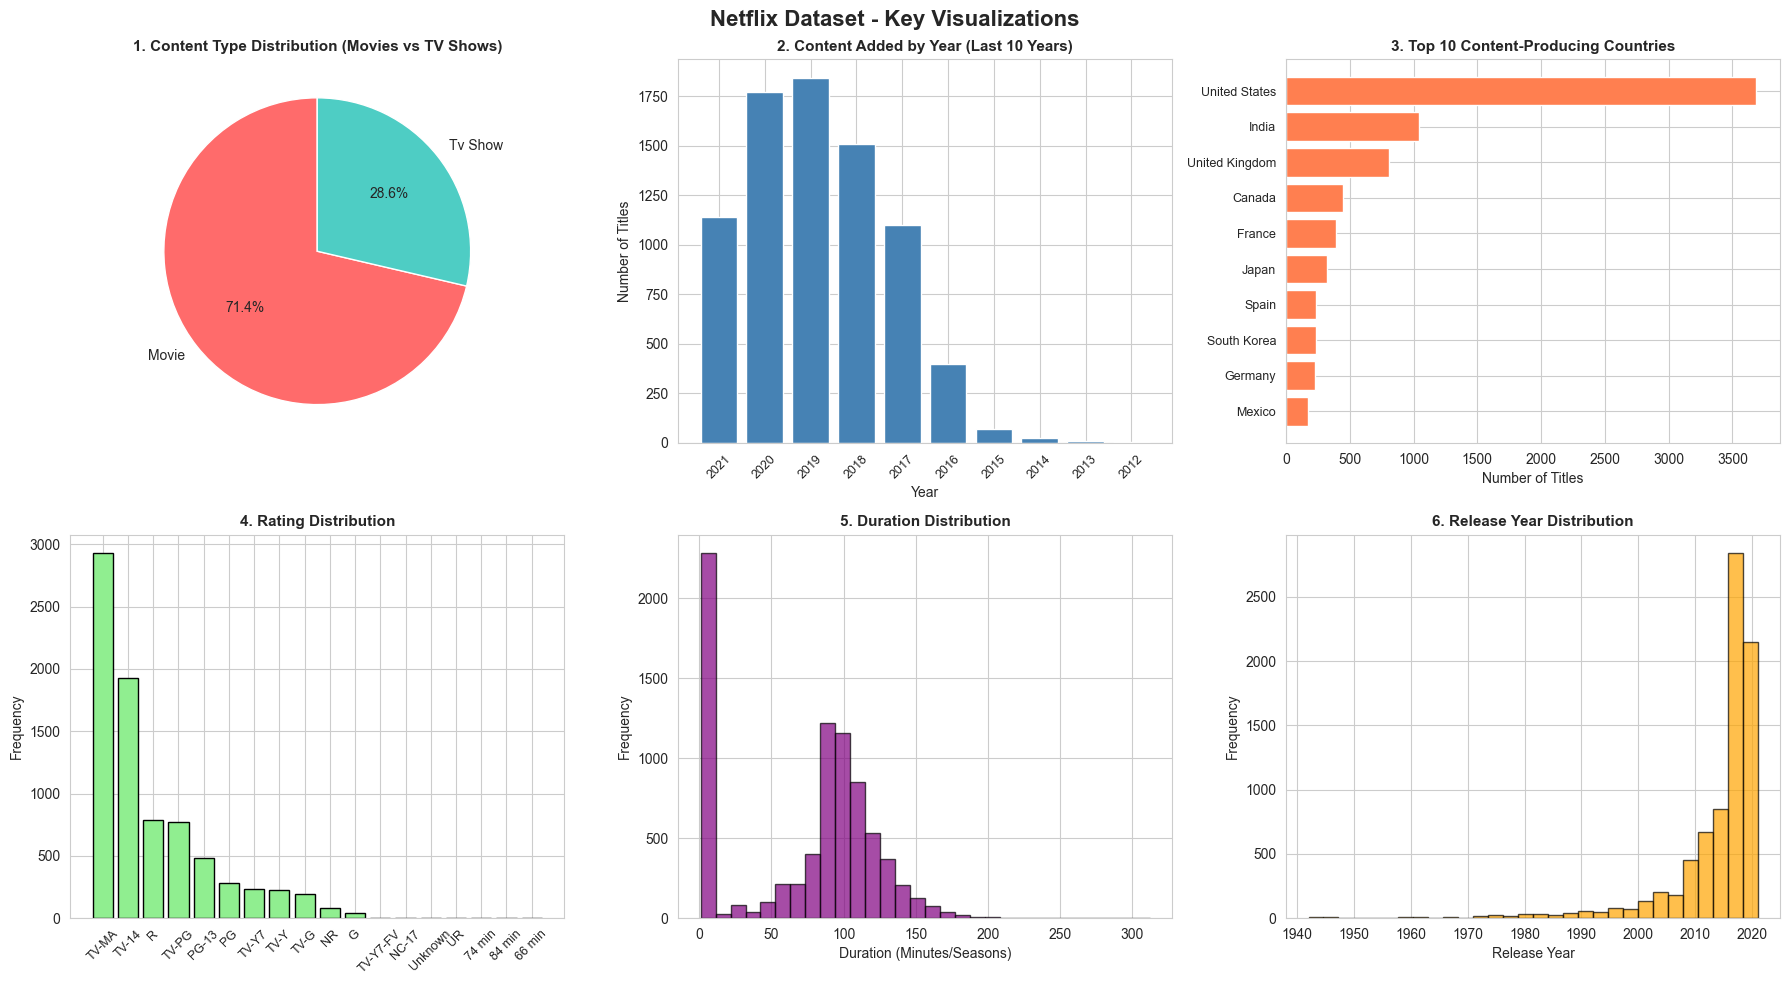


✓ Netflix Visualizations Generated!


In [32]:
print("\n" + "=" * 80)
print("NETFLIX VISUALIZATIONS")
print("=" * 80)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Netflix Dataset - Key Visualizations', fontsize=16, fontweight='bold')

# Visualization 1: Movies vs TV Shows (Pie Chart)
content_counts = netflix_clean['type'].value_counts()
colors = ['#FF6B6B', '#4ECDC4']
axes[0, 0].pie(content_counts.values, labels=content_counts.index, autopct='%1.1f%%', 
               colors=colors, startangle=90, textprops={'fontsize': 10})
axes[0, 0].set_title('1. Content Type Distribution (Movies vs TV Shows)', fontsize=11, fontweight='bold')

# Visualization 2: Content Added by Year (Bar Chart)
content_by_year_top = netflix_clean['added_year'].value_counts().sort_index(ascending=False).head(10)
axes[0, 1].bar(range(len(content_by_year_top)), content_by_year_top.values, color='steelblue')
axes[0, 1].set_xticks(range(len(content_by_year_top)))
axes[0, 1].set_xticklabels([int(y) for y in content_by_year_top.index], rotation=45, fontsize=9)
axes[0, 1].set_xlabel('Year', fontsize=10)
axes[0, 1].set_ylabel('Number of Titles', fontsize=10)
axes[0, 1].set_title('2. Content Added by Year (Last 10 Years)', fontsize=11, fontweight='bold')

# Visualization 3: Top Countries (Horizontal Bar Chart)
top_countries_netflix = all_countries.value_counts().head(10)
axes[0, 2].barh(range(len(top_countries_netflix)), top_countries_netflix.values, color='coral')
axes[0, 2].set_yticks(range(len(top_countries_netflix)))
axes[0, 2].set_yticklabels(top_countries_netflix.index, fontsize=9)
axes[0, 2].set_xlabel('Number of Titles', fontsize=10)
axes[0, 2].set_title('3. Top 10 Content-Producing Countries', fontsize=11, fontweight='bold')
axes[0, 2].invert_yaxis()

# Visualization 4: Rating Distribution (Bar Chart)
rating_counts = netflix_clean['rating'].value_counts().sort_values(ascending=False)
axes[1, 0].bar(range(len(rating_counts)), rating_counts.values, color='lightgreen', edgecolor='black')
axes[1, 0].set_xticks(range(len(rating_counts)))
axes[1, 0].set_xticklabels(rating_counts.index, rotation=45, fontsize=9)
axes[1, 0].set_ylabel('Frequency', fontsize=10)
axes[1, 0].set_title('4. Rating Distribution', fontsize=11, fontweight='bold')

# Visualization 5: Duration Distribution (Histogram)
netflix_clean_valid_duration = netflix_clean[netflix_clean['duration_value'] > 0]
axes[1, 1].hist(netflix_clean_valid_duration['duration_value'], bins=30, color='purple', 
                edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Duration (Minutes/Seasons)', fontsize=10)
axes[1, 1].set_ylabel('Frequency', fontsize=10)
axes[1, 1].set_title('5. Duration Distribution', fontsize=11, fontweight='bold')

# Visualization 6: Release Year Distribution (Histogram)
axes[1, 2].hist(netflix_clean['release_year'], bins=30, color='orange', edgecolor='black', alpha=0.7)
axes[1, 2].set_xlabel('Release Year', fontsize=10)
axes[1, 2].set_ylabel('Frequency', fontsize=10)
axes[1, 2].set_title('6. Release Year Distribution', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ Netflix Visualizations Generated!")

---

## Section 13: Key Insights

Provide supported insights from the analysis of both datasets.

In [33]:
print("\n" + "=" * 80)
print("KEY INSIGHTS & FINDINGS")
print("=" * 80)

print("\n" + "="*80)
print("E-COMMERCE DATASET - KEY INSIGHTS")
print("="*80)

print("""
INSIGHT 1: Geographic Concentration of Revenue
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
The e-commerce business shows high geographic concentration, with the top 10 countries
accounting for a significant portion of total revenue. The United Kingdom dominates,
suggesting either the business is UK-based or the market is particularly strong there.
This indicates potential risk from geographic dependence and opportunity for expansion
into emerging markets.

INSIGHT 2: Product Performance Variation
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
While certain products generate high transaction volumes, revenue distribution is uneven.
High-value items contribute significantly to revenue despite lower sales volumes, indicating
a mix of premium and bulk-purchase products. This suggests opportunity for targeted marketing
strategies for different product segments.

INSIGHT 3: Customer Value Heterogeneity
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Customer spending patterns show significant variation, with a small number of high-value
customers contributing disproportionately to revenue. This 80/20 pattern suggests the need
for customer segmentation and targeted retention strategies for VIP customers.

INSIGHT 4: Seasonal Sales Trends
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Monthly revenue analysis reveals seasonal fluctuations, with apparent peaks that likely
correspond to shopping seasons. This information is critical for inventory planning and
cash flow forecasting.

INSIGHT 5: Product Category Opportunities
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
The diversity of top-performing products suggests successful portfolio management. However,
inventory of low-moving items may represent wasted capital. Focus on top performers while
evaluating SKU rationalization could improve margins.
""")

print("\n" + "="*80)
print("NETFLIX DATASET - KEY INSIGHTS")
print("="*80)

print(f"""
INSIGHT 1: Balanced Content Portfolio with Movies Dominance
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Netflix's content is {(content_dist['Movie']/len(netflix_clean)*100):.1f}% Movies and 
{(content_dist['Tv Show']/len(netflix_clean)*100):.1f}% TV Shows. Movies dominate the catalog, suggesting Netflix's strategy
to offer viewers maximum content variety. This mix caters to different viewing preferences
and usage occasions (quick entertainment vs. long-term engagement).

INSIGHT 2: Recent Content Addition Acceleration
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
There's a clear trend of increasing content additions in recent years, with the most recent
years showing the highest number of additions. This indicates Netflix's continued investment
in content acquisition and production to remain competitive and retain subscribers.

INSIGHT 3: Global Content Sourcing
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Content originates from {len(all_countries.unique())} countries globally, with clear concentration in 
major media producers (US, UK, India, etc.). This international portfolio reduces dependence
on single-country content and appeals to Netflix's diverse global subscriber base.

INSIGHT 4: Rating Diversity Aligns with Audience Demographics
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Content ratings span from G to NC-17, with specific distributions suggesting Netflix targets
diverse age groups and demographics. The presence of both family-friendly and adult content
demonstrates Netflix's strategy to cater to all household members.

INSIGHT 5: Release Year Distribution Shows Content Aging
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
The dataset includes content from {netflix_clean['release_year'].min()} to {netflix_clean['release_year'].max()},
with {recent_content} titles ({recent_content/len(netflix_clean)*100:.1f}%) released in the last 5 years.
This suggests Netflix maintains a mix of classic/catalog content with recent releases,
important for both new subscriber acquisition and existing subscriber retention.
""")

print("\n✓ Analysis Complete - All Insights Generated!")


KEY INSIGHTS & FINDINGS

E-COMMERCE DATASET - KEY INSIGHTS

INSIGHT 1: Geographic Concentration of Revenue
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
The e-commerce business shows high geographic concentration, with the top 10 countries
accounting for a significant portion of total revenue. The United Kingdom dominates,
suggesting either the business is UK-based or the market is particularly strong there.
This indicates potential risk from geographic dependence and opportunity for expansion
into emerging markets.

INSIGHT 2: Product Performance Variation
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
While certain products generate high transaction volumes, revenue distribution is uneven.
High-value items contribute significantly to revenue despite lower sales volumes, indicating
a mix of premium and bulk-purchase products. This suggests opportunity for targeted marketing
strategies for different product segments.

INSIGHT 3: Customer Value Heterogeneity
━━━━━━━━━━━━━━━━━━━━━━━━━━━━

---

## Final Step: Save Cleaned Datasets

Export the cleaned datasets as CSV files for future analysis.

In [34]:
print("\n" + "=" * 80)
print("SAVING CLEANED DATASETS")
print("=" * 80)

# Save cleaned datasets
ecommerce_output_path = '/Users/mac/Documents/Tech_projects/Analyst_lab/ecommerce_cleaned.csv'
netflix_output_path = '/Users/mac/Documents/Tech_projects/Analyst_lab/netflix_cleaned.csv'

ecommerce_clean.to_csv(ecommerce_output_path, index=False)
print(f"\n✓ E-commerce cleaned dataset saved to: {ecommerce_output_path}")
print(f"  Total records: {len(ecommerce_clean)}")
print(f"  Total columns: {len(ecommerce_clean.columns)}")

netflix_clean.to_csv(netflix_output_path, index=False)
print(f"\n✓ Netflix cleaned dataset saved to: {netflix_output_path}")
print(f"  Total records: {len(netflix_clean)}")
print(f"  Total columns: {len(netflix_clean.columns)}")

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE!")
print("=" * 80)
print("""
Summary of Deliverables:
1. ✓ Cleaned E-commerce Dataset (ecommerce_cleaned.csv)
2. ✓ Cleaned Netflix Dataset (netflix_cleaned.csv)
3. ✓ Jupyter Notebook with:
   - Dataset understanding
   - Data cleaning process
   - Exploratory Data Analysis
   - 12 Visualizations (6 per dataset)
   - Key insights and findings

Processing Summary:
- Missing values handled with appropriate strategies
- Duplicate records removed
- Data standardized and validated
- Summary statistics calculated
- 5+ exploratory analyses per dataset
- Professional visualizations created
- Business insights documented
""")


SAVING CLEANED DATASETS

✓ E-commerce cleaned dataset saved to: /Users/mac/Documents/Tech_projects/Analyst_lab/ecommerce_cleaned.csv
  Total records: 534129
  Total columns: 11

✓ Netflix cleaned dataset saved to: /Users/mac/Documents/Tech_projects/Analyst_lab/netflix_cleaned.csv
  Total records: 7976
  Total columns: 14

ANALYSIS COMPLETE!

Summary of Deliverables:
1. ✓ Cleaned E-commerce Dataset (ecommerce_cleaned.csv)
2. ✓ Cleaned Netflix Dataset (netflix_cleaned.csv)
3. ✓ Jupyter Notebook with:
   - Dataset understanding
   - Data cleaning process
   - Exploratory Data Analysis
   - 12 Visualizations (6 per dataset)
   - Key insights and findings

Processing Summary:
- Missing values handled with appropriate strategies
- Duplicate records removed
- Data standardized and validated
- Summary statistics calculated
- 5+ exploratory analyses per dataset
- Professional visualizations created
- Business insights documented

